# 04 | Evaluation

In [1]:
import json

import numpy as np
import pandas as pd

from config.config import Config
from src.evaluation.evaluator import Evaluator

import joblib

In [2]:
cfg = Config()

df_test = pd.read_parquet("../processed/test.parquet")
X_test, t_test, y_test, y_secondary_test = df_test[cfg.feature_cols], df_test[cfg.treatment_col], df_test[cfg.outcome_col], df_test[cfg.secondary_outcome_col]

In [5]:
tlearner = joblib.load(cfg.models_dir / 'tlearner.joblib')
slearner = joblib.load(cfg.models_dir / 'slearner.joblib')
xlearner = joblib.load(cfg.models_dir / 'xlearner.joblib')
# causalforest = joblib.load(cfg.models_dir / 'causalforest.joblib')

In [6]:
evaluator = Evaluator()

In [7]:
result_t = evaluator.evaluate(
    model_name="t-learner",
    y=y_test,
    treatment=t_test,
    tau_hat=tlearner.predict_uplift(X_test),
    )

In [8]:
result_s = evaluator.evaluate(
    model_name="s-learner",
    y=y_test,
    treatment=t_test,
    tau_hat=slearner.predict_uplift(X_test),
    )

In [9]:
result_x = evaluator.evaluate(
    model_name="x-learner",
    y=y_test,
    treatment=t_test,
    tau_hat=xlearner.predict_uplift(X_test),
    )

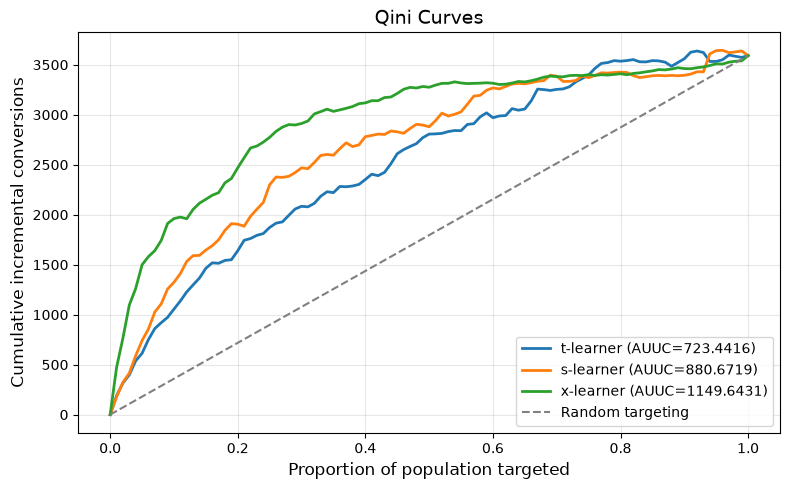

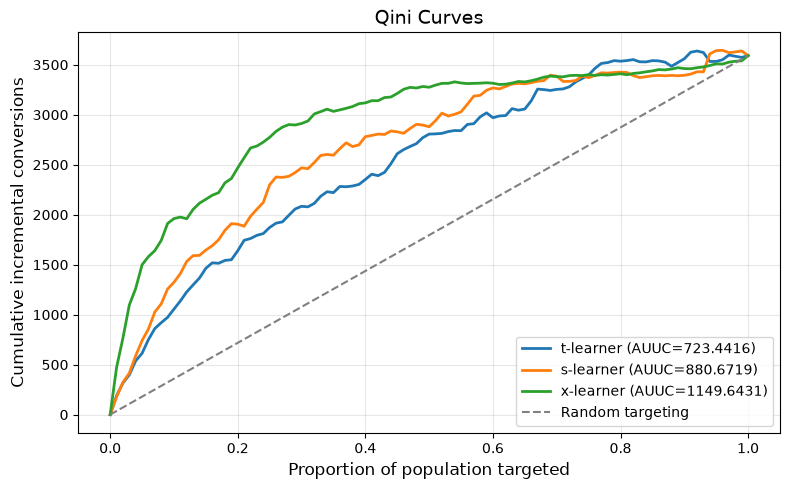

In [ ]:
evaluator.plot_qini(results=[result_t, result_s, result_x], save_path=cfg.results_dir)

In [11]:
evaluator.summary_table(results=[result_t, result_s, result_x])

,model,auuc
0,x-learner,1149.643118
1,s-learner,880.671878
2,t-learner,723.441570
